# Lab 10: Searching Analysis

Paste your completed search functions below, then work through the three experiments.

For each experiment: **run the code**, then **answer the questions** in the markdown cells.

In [3]:
# Paste your four search functions here:

from __future__ import annotations

from typing import Any, Iterable, Tuple

# - sequential_search

def sequential_search(a_list: Iterable[Any], target: Any) -> bool:
    """Return True if ``target`` is present in ``a_list`` using linear scan.

    This is the simplest search algorithm. If the list is empty or the target
    is not found the function returns ``False``.
    """

    for item in a_list:
        if item == target:
            return True
    return False

# - binary_search

def binary_search(a_list: list[Any], target: Any) -> bool:
    """Perform binary search on a **sorted** list.

    The function returns ``True`` if ``target`` exists in ``a_list`` and
    ``False`` otherwise. The list **must** be sorted in ascending order or
    the behavior is undefined.
    """

    low = 0
    high = len(a_list) - 1

    while low <= high:
        mid = (low + high) // 2
        if a_list[mid] == target:
            return True
        elif a_list[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    return False

# - sequential_search_counted

def sequential_search_counted(
    a_list: Iterable[Any], target: Any
) -> Tuple[bool, int]:
    """Like :func:`sequential_search` but also return the number of comparisons.

    The returned count is the number of elements examined before the search
    terminated. When the list is empty the count is zero.
    """

    count = 0
    for item in a_list:
        count += 1
        if item == target:
            return True, count
    return False, count

# - binary_search_counted

def binary_search_counted(a_list: list[Any], target: Any) -> Tuple[bool, int]:
    """Binary search variant that counts comparisons.

    The returned tuple contains ``(found, comparisons)``. ``comparisons`` is
    the number of times an element was inspected.
    """

    low = 0
    high = len(a_list) - 1
    count = 0

    while low <= high:
        mid = (low + high) // 2
        count += 1
        if a_list[mid] == target:
            return True, count
        elif a_list[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    return False, count

In [4]:
# Imports for the experiments
import random
import matplotlib.pyplot as plt

---
## Experiment 1: The Comparison Race

Run both counted searches on sorted lists of increasing size and plot the comparison counts.

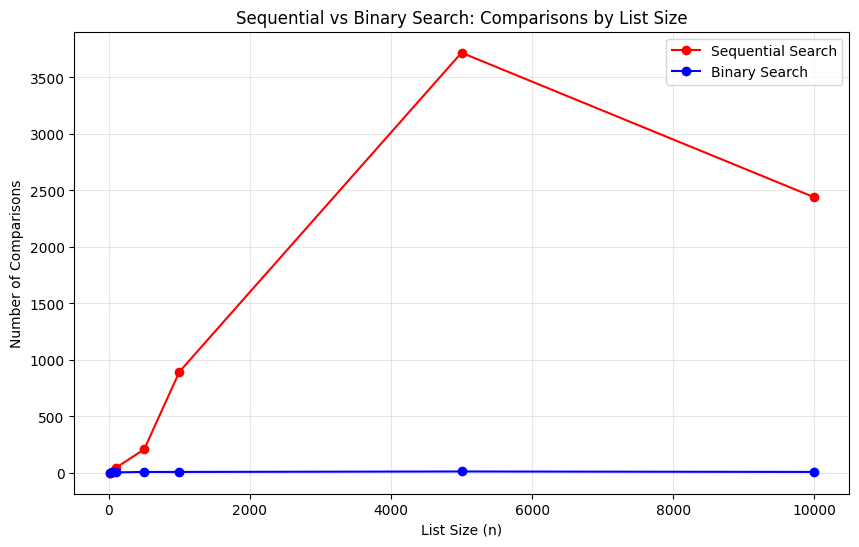

In [10]:
sizes = [10, 50, 100, 500, 1000, 5000, 10000]
seq_counts = []
bin_counts = []

for n in sizes:
    # Generate a sorted list of n items
    test_list = list(range(n))
    # Pick a random target (might or might not be in the list)
    target = random.randint(0, n)

    _, s_count = sequential_search_counted(test_list, target)
    _, b_count = binary_search_counted(test_list, target)

    seq_counts.append(s_count)
    bin_counts.append(b_count)

plt.figure(figsize=(10, 6))
plt.plot(sizes, seq_counts, 'o-', label='Sequential Search', color='red')
plt.plot(sizes, bin_counts, 'o-', label='Binary Search', color='blue')
plt.xlabel('List Size (n)')
plt.ylabel('Number of Comparisons')
plt.title('Sequential vs Binary Search: Comparisons by List Size')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Experiment 1 Questions

**Q1:** Describe the shape of each curve. Why does one grow so much faster than the other?

*Your answer:* The curve for sequential search grows so much faster than the one for binary search because sequential search requires one to look through every item and compare it with the item being searched for, whereas in binary search, one simply compares the middle element to the element being searched and discards half of the list all at once.

**Q2:** At what list size does the difference start to feel significant?

*Your answer:* The difference starts to feel significant at about n = 500.


---
## Experiment 2: Best Case, Worst Case

How much does performance vary depending on *where* the target is (or if it's there at all)?

In [11]:
n = 10000
test_list = list(range(n))

# Sequential search: best case vs worst case
_, seq_best = sequential_search_counted(test_list, test_list[0])      # first element
_, seq_worst = sequential_search_counted(test_list, n + 1)            # not in list

print("=== Sequential Search (n = 10,000) ===")
print(f"Best case  (first element):  {seq_best} comparisons")
print(f"Worst case (not in list):    {seq_worst} comparisons")
print()

# Binary search: does target position matter?
_, bin_first = binary_search_counted(test_list, test_list[0])         # first element
_, bin_last = binary_search_counted(test_list, test_list[-1])         # last element
_, bin_mid = binary_search_counted(test_list, test_list[n // 2])      # middle element
_, bin_miss = binary_search_counted(test_list, n + 1)                 # not in list

print("=== Binary Search (n = 10,000) ===")
print(f"First element:    {bin_first} comparisons")
print(f"Last element:     {bin_last} comparisons")
print(f"Middle element:   {bin_mid} comparisons")
print(f"Not in list:      {bin_miss} comparisons")

=== Sequential Search (n = 10,000) ===
Best case  (first element):  1 comparisons
Worst case (not in list):    10000 comparisons

=== Binary Search (n = 10,000) ===
First element:    13 comparisons
Last element:     14 comparisons
Middle element:   13 comparisons
Not in list:      14 comparisons


### Experiment 2 Questions

**Q3:** Why does sequential search have such a huge gap between best and worst case?

*Your answer:* Sequential search has such a huge gap between best and worst case because, in the best case, one would find their desired item by looking at only one item in the list (typically the first item). On the other hand, in the worst case, one would have to look at all 10,000 items in order to make sure that the desired item is not in the list.


**Q4:** Why is binary search so consistent regardless of where the target is? What about the algorithm causes this?

*Your answer:* Binary search is consistent regardless of the position of the target because, in binary search, one always discards half of the list. The only thing that changes is which half.


---
## Experiment 3: When Is Sorting Worth It?

Binary search requires sorted data, and sorting costs O(n log n). If you have an unsorted list and need to search it *k* times, when does it pay to sort first?

**The two options:**
- **Option A:** Sequential search each time. Total cost: k × n
- **Option B:** Sort first (n log n), then binary search each time. Total cost: n log n + k × log n

For k = 0, **Option A** is better because no sort or search occurs, but Option B requires a sort.

For k = 1, **Option A** is better because a sort is more expensive than a sequential search.

For k = 2, 3, or 4, sequential searches are faster. When k > 4, binary searches are faster for n = 10,000.

### Q5: Calculate the crossover

For n = 10,000: set the two cost formulas equal and solve for *k*. Show your work.

*Your answer:*

k × n = n log n + k log n

Plug in 10,000 for n:

10,000 k = 10,000 log 10,000 + k log 10,000

10,000 k = 40,000 + 4 k

9996 k = 40,000

**k ≈ 4.0016**

In [12]:
import math

n = 10000
log_n = math.log2(n)  # approximately 13.3

# Try different values of k and compare total costs
print(f"n = {n}, log2(n) ≈ {log_n:.1f}")
print(f"{'k':>5}  {'Option A (k×n)':>15}  {'Option B (n·log n + k·log n)':>30}  {'Winner':>8}")
print("-" * 65)

for k in [1, 2, 5, 10, 13, 14, 15, 20, 50, 100]:
    cost_a = k * n
    cost_b = n * log_n + k * log_n
    winner = "A" if cost_a < cost_b else "B" if cost_b < cost_a else "Tie"
    print(f"{k:>5}  {cost_a:>15,.0f}  {cost_b:>30,.0f}  {winner:>8}")

n = 10000, log2(n) ≈ 13.3
    k   Option A (k×n)    Option B (n·log n + k·log n)    Winner
-----------------------------------------------------------------
    1           10,000                         132,890         A
    2           20,000                         132,904         A
    5           50,000                         132,944         A
   10          100,000                         133,010         A
   13          130,000                         133,050         A
   14          140,000                         133,063         B
   15          150,000                         133,076         B
   20          200,000                         133,143         B
   50          500,000                         133,542         B
  100        1,000,000                         134,206         B


### Experiment 3 Questions

**Q6:** Does the experimental crossover match your calculation? If not, why might they differ?

*Your answer:* The experimental crossover does not match my calculation. This is probably because I used **log<sub>10</sub>** instead of **log<sub>2</sub>**.


**Q7:** Give a real-world example where you'd choose Option A (just search without sorting) and one where you'd choose Option B (sort first, then search).

*Your answer:* A real-world example where I would choose option A might be if I was searching through a deck of cards and trying to find a particular card, e.g., the Ten of Hearts.

One where I would choose option B might be if I had a bookshelf and needed to sort my books by title or author so that I could always find my book quickly.